<a href="https://colab.research.google.com/github/CodingWithBilalkhan/Pytorch-Tutorials/blob/main/14_Minst_img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lec 14: Importing MNIST data set

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import  make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Convert MNIST Image files into a tensor or 4-dimensions (# no. of images, height, width, color channels)
transform = transforms.ToTensor()

In [3]:
# Train Data
train_data = datasets.MNIST(root='/cnn_data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.07MB/s]


In [4]:
# Test Data
test_data = datasets.MNIST(root='/cnn_data', train=False, download=True, transform=transform)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

# Lec 15:  Convolutional and Pooling Layers - Deep Learning with PyTorch 15

In [7]:
# Create small batch of images. let say 10
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [8]:
# Define Our CNN Model
# Describe convolutional layer and what it's doing (2 convolutional layers)
# This is just an example in the next video we'll build out the actual model
conv1 = nn.Conv2d(1, 6, 3, 1, )
conv2 = nn.Conv2d(6, 16, 3, 1, )

In [9]:
# Grab 1 MNIST Record/Image
for i, (X_Train, y_train) in enumerate(train_data):
  break


In [10]:
X_Train.shape

torch.Size([1, 28, 28])

In [11]:
x = X_Train.view(1,1,28,28)

In [12]:
# Perform our 1st convolution
x = F.relu(conv1(x)) # Rectified Linear unit for activation function

In [13]:
# 1 single image, 6 is the filter we asked for, 26x26
x.shape

torch.Size([1, 6, 26, 26])

In [14]:
# pass thru the pooling layer
x = F.max_pool2d(x, 2,2) # kernal of 2 and strid of 2

In [15]:
x.shape

torch.Size([1, 6, 13, 13])

In [16]:
# do our 2nd convolution layer
x = F.relu(conv2(x))

In [17]:
x.shape # we don't set padding therefore we losse 2px arround the edges of image

torch.Size([1, 16, 11, 11])

In [18]:
# pooling layer
x = F.max_pool2d(x, 2,2 )

In [19]:
x.shape

torch.Size([1, 16, 5, 5])

# Lec 16 - CNN MODEL - Creating model

In [20]:
# Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)
    # Fully Connected Layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2) # 2x2 is kernal & stride of 2
    # Second pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2) # 2x2 is kernal & stride of 2

    # Review our data to flatten it out
    X = X.view(-1, 16*5*5) # -ive one so we can vary the batch size

    # Fully connected layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)

    return F.log_softmax(X, dim=1)



In [21]:
# Create an instance of model
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [22]:
# Loss function optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # Smaller the learning rate the longer it takes to train



# Lec 17 - Train and Test CNN Model


In [27]:
import time
start_time = time.time()

# Create Variables To Tracks Things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For Loop of Epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0


  # Train
  for b,(X_train, y_train) in enumerate(train_loader):
    b+=1 # start our batches at 1
    y_pred = model(X_train) # get predicted values from the training set. Not flattened 2D
    loss = criterion(y_pred, y_train) # how off are we? Compare the predictions to correct answers in y_train

    predicted = torch.max(y_pred.data, 1)[1] # add up the number of correct predictions. Indexed off the first point
    batch_corr = (predicted == y_train).sum() # how many we got correct from this batch. True = 1, False=0, sum those up
    trn_corr += batch_corr # keep track as we go along in training.

    # Update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # Print out some results
    if b%600 == 0:
      print(f'Epoch: {i}  Batch: {b}  Loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)


  # Test
  with torch.no_grad(): #No gradient so we don't update our weights and biases with test data
    for b,(X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1] # Adding up correct predictions
      tst_corr += (predicted == y_test).sum() # T=1 F=0 and sum away


  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)



current_time = time.time()
total = current_time - start_time
print(f'Training Took: {total/60} minutes!')

Epoch: 0  Batch: 600  Loss: 0.00036099221324548125
Epoch: 0  Batch: 1200  Loss: 0.0001712304074317217
Epoch: 0  Batch: 1800  Loss: 0.0005378525820560753
Epoch: 0  Batch: 2400  Loss: 0.027378559112548828
Epoch: 0  Batch: 3000  Loss: 0.0002596829435788095
Epoch: 0  Batch: 3600  Loss: 8.657989383209497e-05
Epoch: 0  Batch: 4200  Loss: 0.00040106248343363404
Epoch: 0  Batch: 4800  Loss: 1.2349883036222309e-05
Epoch: 0  Batch: 5400  Loss: 0.00046615247265435755
Epoch: 0  Batch: 6000  Loss: 0.000162848416948691
Epoch: 1  Batch: 600  Loss: 6.399912672350183e-05
Epoch: 1  Batch: 1200  Loss: 0.0002539866545703262
Epoch: 1  Batch: 1800  Loss: 0.0003175207821186632
Epoch: 1  Batch: 2400  Loss: 8.683211490279064e-05
Epoch: 1  Batch: 3000  Loss: 0.00015392867499031126
Epoch: 1  Batch: 3600  Loss: 0.12387670576572418
Epoch: 1  Batch: 4200  Loss: 0.00015394852380268276
Epoch: 1  Batch: 4800  Loss: 0.00032526275026611984
Epoch: 1  Batch: 5400  Loss: 0.08193918317556381
Epoch: 1  Batch: 6000  Loss: 1.2

# Lec 18 - Graph CNN Results

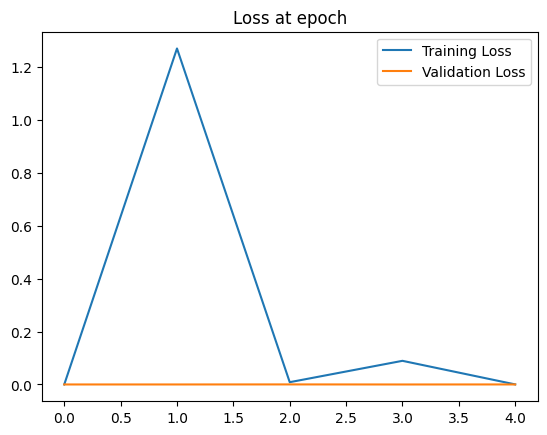

In [30]:
# Graph the loss at each epoch
test_losses_float = [tl.item() for tl in test_losses] # Convert test_losses (list of tensors) to list of floats
plt.plot(train_losses, label='Training Loss') # Use 'label' not 'Label'
plt.plot(test_losses_float, label='Validation Loss') # Use 'label' and the float version of test_losses
plt.title('Loss at epoch') # Correct way to set title
plt.legend()

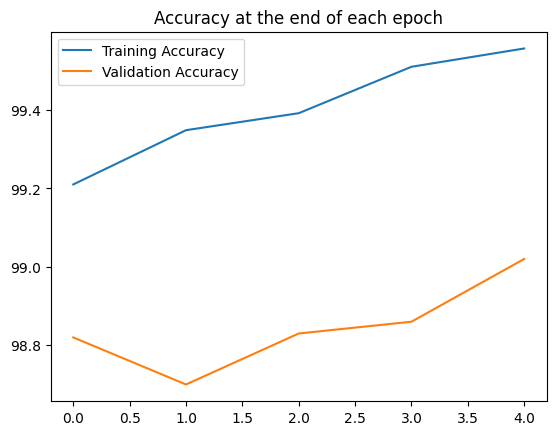

In [32]:
# Graph the accuracy at the end of each epcoh
plt.plot([t/600 for t in train_correct], label='Training Accuracy')
plt.plot([t/100 for t in test_correct], label='Validation Accuracy')
plt.title("Accuracy at the end of each epoch")
plt.legend()

In [34]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [35]:
with torch.no_grad():
  correct = 0
  for X_test,y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val, 1)[1]
    correct += (predicted == y_test).sum()


In [38]:
# Did for correct
correct.item()/len(test_data)*100

99.02